<a href="https://colab.research.google.com/github/julia-zhmurko/JuliaZhmurko-ML/blob/main/%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA%D0%B8_%D0%B4%D0%BE_%D0%BB%D0%B5%D0%BA%D1%86%D1%96%D0%B9/%D0%96%D0%BC%D1%83%D1%80%D0%BA%D0%BE_%D0%AE%D0%BB%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_10_%22%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_26_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук: лінійна регресія та регуляризація

**Курс:** Машинне навчання  
**Тема:** Linear Regression, Ridge, Lasso, Elastic Net

Цей ноутбук відповідає лекції про лінійну регресію та побудований як практичне продовження теоретичного матеріалу. У прикладах послідовно розглядаються проста й множинна лінійна регресія, метрики, залишки, недонавчання і перенавчання, L1/L2-регуляризація, Ridge, Lasso, Elastic Net, масштабування, крос-валідація, `GridSearchCV`, `Pipeline`, `ColumnTransformer` та навчальні криві.

У ноутбуці є два типи комірок:

- **Приклад** — готовий код, який потрібно виконати, проаналізувати та пояснити.
- **Самостійне завдання** — окрема кодова комірка з позначкою `TODO`. Її потрібно заповнити власноруч. Готового розв'язку в ноутбуці немає.

Рекомендація: виконувати комірки послідовно зверху вниз і після кожного блоку формулювати короткий висновок своїми словами.

**Автор:** студентка групи ФІТ 4-10 Жмурко Юлія Андріївна

**Була присутня на парі (01.10.2026)**

## 0. Імпорт бібліотек і налаштування середовища

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Середовище готове до роботи.')

Середовище готове до роботи.


###**Пояснення:**

Імпортовано бібліотеки `numpy` та `pandas` для обробки даних, а також `matplotlib.pyplot` для візуалізації результатів.

Завантажено датасет `load_diabetes` і константну модель `DummyRegressor` для порівняння результатів складніших моделей.

Імпортовано класичну лінійну регресію (`LinearRegression`) та її регуляризовані модифікації (`Ridge`, `Lasso`, `ElasticNet`).

Підключено метрики помилок ($MAE$, $MSE$, $RMSE$, $R^2$), інструменти для розбиття даних (`train_test_split`), крос-валідації (`KFold`, `cross_validate`), підбору гіперпараметрів (`GridSearchCV`) та побудови кривих навчання (`learning_curve`).

Завантажено інструменти для масштабування (`StandardScaler`), генерації поліноміальних ознак (`PolynomialFeatures`), кодування (`OneHotEncoder`), обробки пропусків (`SimpleImputer`), а також конструювання конвеєрів (`Pipeline`, `ColumnTransformer`).

Зафіксовано значення `RANDOM_STATE = 42` та `seed` для `NumPy`, що гарантує однаковість результатів при повторних запусках.


## 1. Проста лінійна регресія

Для однієї ознаки модель має вигляд

$$
\hat y = b_0 + b_1x.
$$

Тут $b_0$ — вільний член, а $b_1$ показує, на скільки одиниць у середньому змінюється прогноз $\hat y$ при збільшенні $x$ на одну одиницю.

Нижче згенеруємо дані, у яких істинна залежність приблизно дорівнює $y=5+2.4x$, але спостереження містять випадковий шум.

Вільний член b0: 4.907
Коефіцієнт b1: 2.451


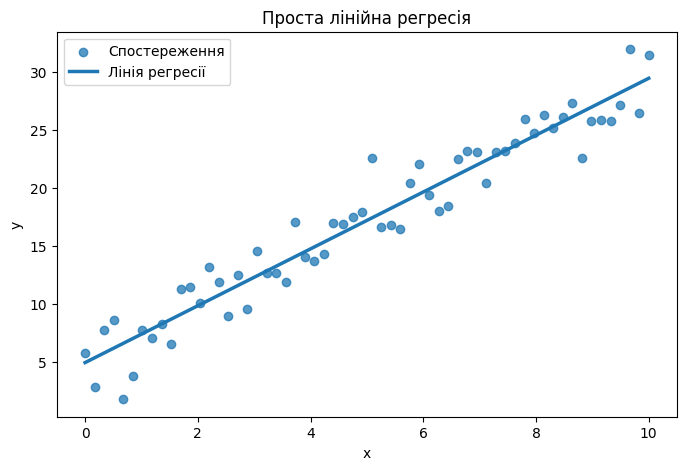

In [107]:
rng = np.random.default_rng(RANDOM_STATE)

X_simple = np.linspace(0, 10, 60).reshape(-1, 1)
y_simple = 5 + 2.4 * X_simple.ravel() + rng.normal(0, 2.5, size=len(X_simple))

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)
y_simple_pred = simple_model.predict(X_simple)

print(f'Вільний член b0: {simple_model.intercept_:.3f}')
print(f'Коефіцієнт b1: {simple_model.coef_[0]:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_simple.ravel(), y_simple, alpha=0.75, label='Спостереження')
plt.plot(X_simple.ravel(), y_simple_pred, linewidth=2.5, label='Лінія регресії')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Проста лінійна регресія')
plt.legend()
plt.show()

**Що потрібно побачити.** Коефіцієнт нахилу має бути близьким до 2.4, але не обов'язково дорівнювати йому точно, оскільки дані містять шум. `fit()` оцінює параметри за навчальними даними, а `predict()` лише обчислює прогноз для заданих значень ознак.

###**Пояснення:**

Згенеровано 60 точок за формулою $y = 5 + 2.4x$ із додаванням нормального шуму $\mathcal{N}(0, 2.5)$.

За допомогою `LinearRegression()` та методу `.fit()` оцінено параметри лінії, після чого за допомогою `.predict()` обчислено прогнози $\hat{y}$.

Модель знайшла параметри $b_0 \approx 4.907$ (вільний член) та $b_1 \approx 2.451$ (коефіцієнт нахилу), які дуже близькі до істинних значень ($5$ і $2.4$), а невелика різниця зумовлена наявністю випадкового шуму в даних.

На графіку точкові спостереження (`plt.scatter`) добре лягають уздовж підігнаної прямої регресії (`plt.plot`), що підтверджує правильність апроксимації лінійної залежності.

### Самостійне завдання 1

1. Створіть новий масив `X_new` зі значеннями 2, 5 і 8.
2. Отримайте прогнози моделі.
3. Виведіть таблицю з колонками `x` та `prediction`.
4. Одним реченням поясніть зміст отриманого коефіцієнта `b1`.

In [108]:
# TODO: Самостійне завдання 1
# 1
X_new = np.array([[2], [5], [8]])

# 2
predictions = simple_model.predict(X_new)

# 3
df_results = pd.DataFrame({
    'x': X_new.flatten(),
    'prediction': predictions
})

display(df_results)

,x,prediction
0,2,9.809730
1,5,17.163214
2,8,24.516697


###**Пояснення:**

Коефіцієнт $b_1$ показує, що при збільшенні значення ознаки $x$ на $1$ одиницю, прогнозоване значення цільової змінної $y$ зростає в середньому на $2.451$ одиниці.  

## 2. Метод найменших квадратів і ручний розрахунок коефіцієнтів

Для простої регресії коефіцієнт нахилу можна обчислити без готової моделі:

$$
b_1 = \frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2},
\qquad
b_0 = \bar y-b_1\bar x.
$$

Чисельник у формулі для $b_1$ відображає спільну зміну $x$ і $y$, а знаменник — варіативність самої ознаки $x$. Після знаходження нахилу вільний член підбирається так, щоб пряма проходила через точку $(\bar x, \bar y)$.

In [109]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3.0, 5.2, 6.8, 9.1, 10.9])

x_bar = x.mean()
y_bar = y.mean()

b1_manual = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0_manual = y_bar - b1_manual * x_bar

model_check = LinearRegression().fit(x.reshape(-1, 1), y)

print(f'Ручний розрахунок: b0={b0_manual:.4f}, b1={b1_manual:.4f}')
print(f'scikit-learn:     b0={model_check.intercept_:.4f}, b1={model_check.coef_[0]:.4f}')

Ручний розрахунок: b0=1.0900, b1=1.9700
scikit-learn:     b0=1.0900, b1=1.9700


###**Пояснення:**

Спочатку розраховуються середні значення $\bar{x}$ (`x_bar`) та $\bar{y}$ (`y_bar`).

Коефіцієнт нахилу ($b_1$) обчислюється як відношення коваріації $x$ та $y$ (чисельник) до дисперсії $x$ (знаменник).

Вільний член ($b_0$) знаходиться з умови, що регресійна лінія обов'язково проходить через точку середніх значень $(\bar{x}, \bar{y})$.

Створюється та навчається модель `LinearRegression()`, після чого виводяться її інтерпретовані параметри `intercept_` та `coef_`.

Результати ручного обчислення ($b_0 = 1.0900, b_1 = 1.9700$) та оцінки бібліотеки `scikit-learn` повністю збігаються, що підтверджує, що в основі `LinearRegression` лежать математичні формули МНК.

### Самостійне завдання 2

Використайте масиви `x2 = [2, 4, 6, 8, 10]` та `y2 = [7, 11, 16, 19, 25]`. Власноруч обчисліть `b0` і `b1` за формулами, а потім перевірте результат за допомогою `LinearRegression`.

In [110]:
# TODO: Самостійне завдання 2
x2 = np.array([2, 4, 6, 8, 10], dtype = float)
y2 = np.array([7, 11, 16, 19, 25], dtype = float)

# середні значення
x2_bar = x2.mean()
y2_bar = y2.mean()

# обчислення b1 та b0 вручну за формулами МНК
b1_manual = ((x2 - x2_bar) * (y2 - y2_bar)).sum() / ((x2 - x2_bar) ** 2).sum()
b0_manual = y2_bar - b1_manual * x2_bar

# перевірка за допомогою LinearRegression з scikit-learn
model2 = LinearRegression().fit(x2.reshape(-1, 1), y2)

print(f'Ручний розрахунок: b0 = {b0_manual:.4f}, b1 = {b1_manual:.4f}')
print(f'scikit-learn:      b0 = {model2.intercept_:.4f}, b1 = {model2.coef_[0]:.4f}')

Ручний розрахунок: b0 = 2.4000, b1 = 2.2000
scikit-learn:      b0 = 2.4000, b1 = 2.2000


###**Пояснення:**

Спочатку створюються тестові масиви x2 та y2 з плаваючою крапкою (`dtype=float`).

Далі виконується обчислення середніх значень змінних: $\bar{x} = 6.0$ та $\bar{y} = 15.6$.

За формулами методу найменших квадратів знаходиться коефіцієнт нахилу $b_1 = 2.2000$ та вільний член $b_0 = 2.4000$.

На наступному кроці проводиться навчання оцінювача `LinearRegression()` на підготовлених даних.

Результати аналітичного розрахунку та оцінки бібліотеки `scikit-learn` повністю збігаються ($b_0 = 2.4000$, $b_1 = 2.2000$), що підтверджує правильність зроблених обчислень.

## 3. Множинна лінійна регресія

У випадку кількох ознак модель має вигляд

$$
\hat y = b_0+b_1x_1+b_2x_2+\dots+b_px_p.
$$

Коефіцієнт $b_j$ інтерпретується як зміна прогнозу при збільшенні ознаки $x_j$ на одну одиницю **за інших рівних умов**, тобто при фіксованих значеннях інших ознак.

Для практики використаємо вбудований набір `diabetes`, тому ноутбук не потребує завантаження даних з Інтернету.

In [111]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.copy()
y = diabetes.target.copy()

print('Розмір X:', X.shape)
print('Розмір y:', y.shape)
display(X.head())

Розмір X: (442, 10)
Розмір y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [112]:
y

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [113]:
multi_model = LinearRegression()
multi_model.fit(X, y)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': multi_model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

display(coef_table)
print(f'Intercept: {multi_model.intercept_:.3f}')

,feature,coefficient
4,s1,-792.175639
8,s5,751.273700
2,bmi,519.845920
5,s2,476.739021
3,bp,324.384646
1,sex,-239.815644
7,s4,177.063238
6,s3,101.043268
9,s6,67.626692
0,age,-10.009866


Intercept: 152.133


Зверніть увагу: великий за модулем коефіцієнт не завжди означає, що ознака є «найважливішою». Порівняння коефіцієнтів залежить від масштабу ознак та їх взаємної кореляції.

###**Пояснення:**

За допомогою функції `load_diabetes`(`as_frame=True`) завантажується стандартний датасет про цукровий діабет із бібліотеки `scikit-learn` у вигляді об'єкта `DataFrame`.

Матриця незалежних ознак $X$ містить 10 фізіологічних показників пацієнтів, а цільова вектор-змінна $y$ відповідає за кількісний показник прогресування хвороби.

Вхідний датасет налічує 442 спостереження (пацієнти) та 10 ознак (`X.shape = (442, 10)`), а значення ознак попередньо стандартизовані.

Побудовано та навчено модель множинної лінійної регресії `LinearRegression()` на 10 ознаках.

Значення коефіцієнтів $b_j$ (`coef_`) об'єднано з назвами ознак у `DataFrame` та посортовано за їхнім абсолютним значенням (`key=np.abs, ascending=False`).

Найсильніший лінійний вплив на прогноз мають показники `s1` (-792.18), `s5` (751.27) та `bmi` (519.85).



## 4. Train/test та наївний baseline

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)

print('Baseline RMSE:', root_mean_squared_error(y_test, baseline_pred))
print('LinearRegression RMSE:', root_mean_squared_error(y_test, linear_pred))

Baseline RMSE: 73.22249283682244
LinearRegression RMSE: 53.85344583676593


`DummyRegressor` не використовує закономірності в ознаках і в цьому прикладі прогнозує середнє значення цільової змінної з train. Якщо реальна модель не перевершує такий baseline, необхідно переглянути ознаки, постановку задачі або сам алгоритм.

###**Пояснення:**

Датасет розділено на навчальну (`X_train`, `y_train`) та тестову (`X_test`, `y_test`) вибірки у співвідношенні 80/20 (`test_size=0.2`) для об'єктивного оцінювання якості моделей на нових даних.

Навчено просту бейзлайн-модель із стратегією `strategy='mean'`, яка завжди прогнозує константне середнє значення `target` з навчальної вибірки, ігноруючи вхідні ознаки.

Навчено модель лінійної регресії на тій самій навчальній вибірці та отримано прогнози для тестових даних.

Модель `LinearRegression()` показує суттєво меншу помилку, ніж `DummyRegressor()` (RMSE знизився з 73.22 до 53.85), що підтверджує наявність реальних взаємозв'язків між вхідними ознаками та цільовою змінною.

## 5. Метрики якості регресії

У лекції розглядалися MAE, MSE, RMSE та $R^2$. Вони відповідають на різні питання.

- **MAE** показує середню абсолютну величину помилки.
- **MSE** сильніше штрафує великі помилки через піднесення залишку до квадрата.
- **RMSE** є коренем з MSE і вимірюється в тих самих одиницях, що й цільова змінна.
- **$R^2$** порівнює модель із прогнозом середнім значенням цільової змінної. На нових даних він може бути від'ємним.

In [115]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': (np.abs(y_true - y_pred) / y_true).mean() * 100
    }

metrics_baseline = regression_metrics(y_test, baseline_pred)
metrics_linear = regression_metrics(y_test, linear_pred)

pd.DataFrame([metrics_baseline, metrics_linear], index=['DummyRegressor', 'LinearRegression'])

,MAE,MSE,RMSE,R2,MAPE
DummyRegressor,64.006461,5361.533457,73.222493,-0.011963,62.791796
LinearRegression,42.794095,2900.193628,53.853446,0.452603,37.499826


###**Пояснення:**

Визначено функцію, яка приймає дійсні (`y_true`) та спрогнозовані (`y_pred`) значення й повертає словник із чотирма основними метриками: $MAE$ (Mean Absolute Error) - середня абсолютна помилка, $MSE$ (Mean Squared Error) - середньоквадратична помилка, $RMSE$ (Root Mean Squared Error) - корінь із середньоквадратичної помилки та $R^2$ (R-squared / Коефіцієнт детермінації) - частка дисперсії цільової змінної, пояснена моделлю.

Розраховано метрики для прогнозу `DummyRegressor` та `LinearRegression` на тестових даних, після чого їх об'єднано в зручний `DataFrame`.`

`DummyRegressor` показує високі абсолютні й квадратні помилки ($\text{MAE} \approx 64.01$, $\text{RMSE} \approx 73.22$) та від'ємне значення $R^2 \approx -0.012$, що підтверджує непридатність прогнозування простим середнім на нових даних.

`LinearRegression` демонструє суттєве зменшення всіх типів помилок ($\text{MAE} \approx 42.79$, $\text{RMSE} \approx 53.85$) та коефіцієнт детермінації $R^2 \approx 0.453$, що свідчить про те, що модель пояснює близько 45.3% варіативності даних.

### Самостійне завдання 3

Обчисліть MAE, RMSE і $R^2$ окремо, **не використовуючи** функцію `regression_metrics`. Порівняйте `DummyRegressor` і `LinearRegression`. У Markdown-комірці нижче поясніть, яка модель краща і чому не варто робити висновок лише за однією метрикою.

In [116]:
# TODO: Самостійне завдання 3
mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = root_mean_squared_error(y_test, baseline_pred)
r2_base = r2_score(y_test, baseline_pred)

mae_lin = mean_absolute_error(y_test, linear_pred)
rmse_lin = root_mean_squared_error(y_test, linear_pred)
r2_lin = r2_score(y_test, linear_pred)

print("--- DummyRegressor ---")
print(f"MAE:  {mae_base:.4f}")
print(f"RMSE: {rmse_base:.4f}")
print(f"R2:   {r2_base:.4f}\n")

print("--- LinearRegression ---")
print(f"MAE:  {mae_lin:.4f}")
print(f"RMSE: {rmse_lin:.4f}")
print(f"R2:   {r2_lin:.4f}")

--- DummyRegressor ---
MAE:  64.0065
RMSE: 73.2225
R2:   -0.0120

--- LinearRegression ---
MAE:  42.7941
RMSE: 53.8534
R2:   0.4526


**Ваш висновок:**  
_Напишіть 2–4 речення після виконання розрахунків._

###**Пояснення:**

Модель `LinearRegression` є значно кращою за `DummyRegressor`, оскільки показує меншу абсолютну та середньоквадратичну помилку ($\text{MAE} \approx 42.79$, $\text{RMSE} \approx 53.85$), а також додатний коефіцієнт детермінації ($R^2 \approx 0.453$) проти від'ємного у `DummyRegressor`.

Робити висновок лише за однією метрикою не варто, адже вони вимірюють різні аспекти якості: $\text{MAE}$ показує середнє відхилення, $\text{RMSE}$ чутливий до великих викидів (штрафує їх сильніше), а $R^2$ оцінює частку поясненої дисперсії відносно наївного прогнозу.

Комплексний аналіз усіх трьох метрик дає повну картину точності та стабільності моделі.

## 6. Залишки та діагностика моделі

Залишок для об'єкта визначається як

$$
e_i = y_i-\hat y_i.
$$

Якщо модель добре описує систематичну частину залежності, на графіку `prediction → residual` не повинно бути вираженої структури. Дуга може вказувати на нелінійність, а «воронка» — на зміну дисперсії помилки.

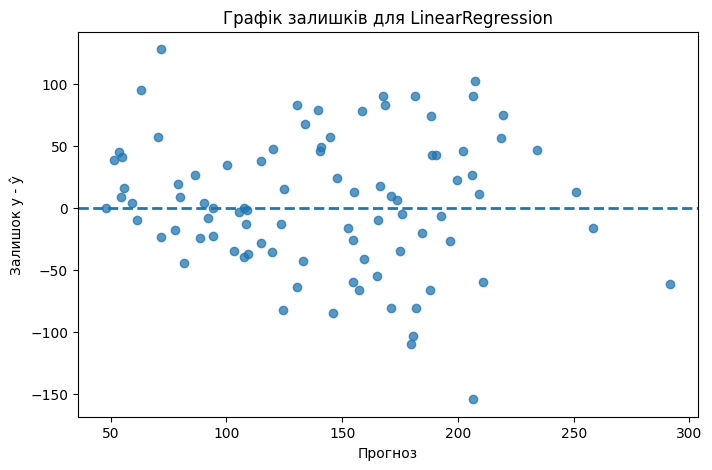

In [117]:
residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))
plt.scatter(linear_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle='--', linewidth=2)
plt.xlabel('Прогноз')
plt.ylabel('Залишок y - ŷ')
plt.title('Графік залишків для LinearRegression')
plt.show()

###**Пояснення:**

Обчислено вектор помилок `residuals = y_test - linear_pred`, який показує різницю між фактичними значеннями цільової змінної та спрогнозованими модельними значеннями.

Побудовано діаграму розсіювання, де по осі $X$ відкладено спрогнозовані значення (`linear_pred`), а по осі $Y$ - відповідні залишки (`residuals`). Пунктирна лінія на рівні $0$ відповідає ідеальному збігу прогнозу та реальності.

Точки розподілені хаотично навколо нульової лінії, що свідчить про відсутність вираженої нелінійної залежності, яку модель не змогла б урахувати.

Дисперсія залишків залишається відносно стабільною вздовж усього діапазону прогнозів (відсутня форма «воронки» чи розширення), що підтверджує виконуваність припущень лінійної регресії.

## 7. Недонавчання і перенавчання на поліноміальній регресії

Лінійна модель може недонавчатися, якщо реальна залежність нелінійна. Один зі способів збільшити гнучкість — створити поліноміальні ознаки. Але занадто високий ступінь полінома збільшує ризик перенавчання.

Порівняємо ступені 1, 4 і 15 на невеликій синтетичній вибірці.

In [118]:
rng = np.random.default_rng(RANDOM_STATE)
X_poly = np.sort(rng.uniform(-3, 3, 45)).reshape(-1, 1)
y_true_poly = np.sin(X_poly.ravel()) + 0.25 * X_poly.ravel()
y_poly = y_true_poly + rng.normal(0, 0.22, size=len(X_poly))

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_poly, y_poly, test_size=0.35, random_state=RANDOM_STATE
)

def fit_polynomial(degree):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression()),
    ])
    model.fit(X_p_train, y_p_train)
    train_pred = model.predict(X_p_train)
    test_pred = model.predict(X_p_test)
    return model, {
        'degree': degree,
        'train_rmse': root_mean_squared_error(y_p_train, train_pred),
        'test_rmse': root_mean_squared_error(y_p_test, test_pred),
    }

results = []
models_poly = {}
for degree in [1, 4, 15]:
    m, res = fit_polynomial(degree)
    models_poly[degree] = m
    results.append(res)

pd.DataFrame(results)

,degree,train_rmse,test_rmse
0,1,0.392868,0.465437
1,4,0.144969,0.203183
2,15,0.091024,0.244266


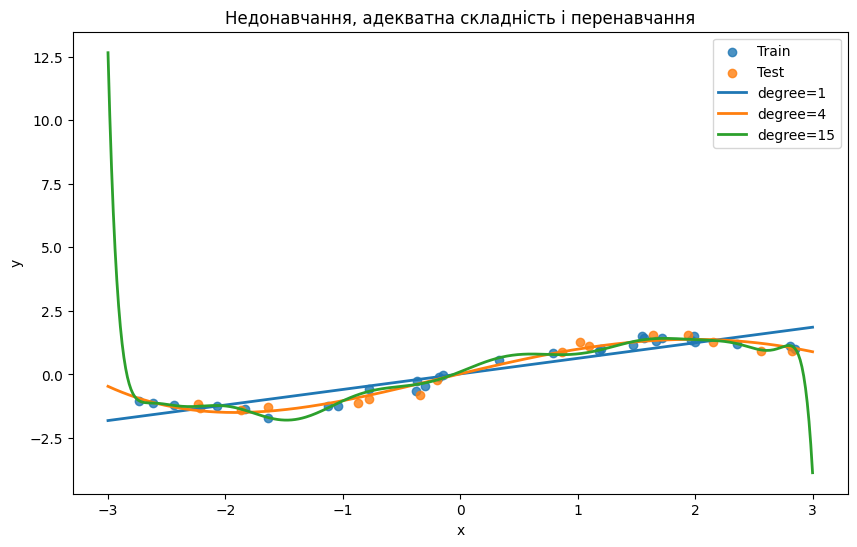

In [119]:
grid = np.linspace(-3, 3, 400).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_p_train, y_p_train, label='Train', alpha=0.8)
plt.scatter(X_p_test, y_p_test, label='Test', alpha=0.8)

for degree in [1, 4, 15]:
    plt.plot(grid, models_poly[degree].predict(grid), linewidth=2, label=f'degree={degree}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Недонавчання, адекватна складність і перенавчання')
plt.legend()
plt.show()

###**Пояснення:**

Згенеровано синтетичний датасет із нелінійною залежністю $y = \sin(x) + 0.25x + \epsilon$.

Створено пайплайн `Pipeline`, який послідовно генерує поліноміальні ознаки (`PolynomialFeatures`) та навчає лінійну регресію (`LinearRegression`).

При `degree = 1` проста пряма лінія не здатна описувати синусоїдальну форму даних. Модель показує високі помилки як на `train` ($\text{train_rmse} \approx 0.393$), так і на `test` ($\text{test_rmse} \approx 0.465$).

При `degree = 4` модель добре підлаштовується під гладку форму функції, досягаючи найкращої узагальнюючої здатності з мінімальною помилкою на тестових даних ($\text{test_rmse} \approx 0.203$).

При `degree = 15` поліном високого ступеня намагається пройти через кожну шумну точку навчальної вибірки, що забезпечує найменшу помилку на `train` ($\text{train_rmse} \approx 0.091$), але призводить до різкого зростання помилки на `test` ($\text{test_rmse} \approx 0.244$).

### Самостійне завдання 4

1. Додайте до порівняння ступені 2, 6 і 10.
2. Побудуйте таблицю `degree`, `train_rmse`, `test_rmse`.
3. Визначте ступінь із найменшим `test_rmse`.
4. Поясніть, чому мінімальна train-помилка не гарантує найкращої моделі.

In [120]:
# TODO: Самостійне завдання 4
degrees = [1, 2, 4, 6, 10, 15]
results_task4 = []

for degree in degrees:
    _, res = fit_polynomial(degree)
    results_task4.append(res)

df_results = pd.DataFrame(results_task4)
display(df_results)

# Визначення ступеня з найменшим test_rmse
best_row = df_results.loc[df_results['test_rmse'].idxmin()]

print(f"\nНайкращий ступінь за test_rmse: {int(best_row['degree'])} (test_rmse = {best_row['test_rmse']:.4f})")

,degree,train_rmse,test_rmse
0,1,0.392868,0.465437
1,2,0.392821,0.463992
2,4,0.144969,0.203183
3,6,0.137065,0.196267
4,10,0.129074,0.191782
5,15,0.091024,0.244266



Найкращий ступінь за test_rmse: 10 (test_rmse = 0.1918)


###**Пояснення:**

За результатами обчислень найменшу помилку на тестовій вибірці показує модель зі ступенем **`degree = 10`** (`test_rmse ≈ 0.1918`). При збільшенні ступеня до 15 помилка на тесті починає зростати (`test_rmse ≈ 0.2443`), що вказує на перенавчання.

Мінімальна помилка на `train` спостерігається при `degree = 15` (`train_rmse ≈ 0.0910`).

Це відбувається тому, що складніша модель здатна ідеально "підлаштуватися" під усі точки навчальної вибірки, включаючи випадковий шум. Проте таке надмірне підлаштування призводить до втрати узагальнюючої здатності, і на нових (тестових) даних модель демонструє значно гірші результати.

 Оцінювати якість моделі потрібно саме за тестовою метрикою (`test_rmse`).

## 8. Регуляризація: загальна ідея

Коли модель має багато ознак або ознаки сильно корельовані, коефіцієнти можуть ставати нестабільними. Регуляризація додає до функції втрат штраф за великі коефіцієнти.

Для Ridge використовується L2-штраф

$$
\text{MSE}+\alpha\sum_{j=1}^{p} b_j^2,
$$

для Lasso — L1-штраф

$$
\text{MSE}+\alpha\sum_{j=1}^{p}|b_j|.
$$

Параметр $\alpha$ керує силою регуляризації. Якщо $\alpha=0$, штраф зникає. Надто велике $\alpha$ може надмірно стиснути коефіцієнти й спричинити недонавчання.

## 9. Чому перед Ridge, Lasso та Elastic Net потрібне масштабування

In [121]:
# Штучно змінюємо масштаби кількох ознак, щоб побачити роль StandardScaler.
X_scaled_demo = X.copy()
X_scaled_demo['bmi'] = X_scaled_demo['bmi'] * 1000
X_scaled_demo['bp'] = X_scaled_demo['bp'] * 0.01

Xsd_train, Xsd_test, ysd_train, ysd_test = train_test_split(
    X_scaled_demo, y, test_size=0.2, random_state=RANDOM_STATE
)

ridge_no_scaling = Ridge(alpha=10.0).fit(Xsd_train, ysd_train)
ridge_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(Xsd_train, ysd_train)

print('Ridge без масштабування RMSE:', root_mean_squared_error(ysd_test, ridge_no_scaling.predict(Xsd_test)))
print('Ridge + StandardScaler RMSE:', root_mean_squared_error(ysd_test, ridge_pipeline.predict(Xsd_test)))

Ridge без масштабування RMSE: 62.25349241861679
Ridge + StandardScaler RMSE: 53.626287568895194


Штраф застосовується безпосередньо до коефіцієнтів. Якщо ознаки вимірюються в дуже різних масштабах, одна й та сама величина коефіцієнта не має однакового змісту. Тому `StandardScaler` зазвичай включають у `Pipeline` перед регуляризованою лінійною моделлю.

###**Пояснення:**

У коді штучно змінено масштаби двух ознак: значення `bmi` помножено на $1000$ (дуже великі числа), а значення `bp` помножено на $0.01$ (дуже малі числа).

Далі порівняно дві `Ridge`-моделі (з однакової величиною штрафу $\alpha=10.0$): першу натреновано на сирих невідмасштабованих даних, а другу — через `Pipeline` із застосуванням `StandardScaler`.

Без масштабування ($RMSE$ ≈ 62.25), оскільки штраф `L2` ($\alpha \sum b_j^2$) діє на коефіцієнти однаково, ознаки з великими значеннями (наприклад, `bmi`) змушують модель мати дуже малі коефіцієнти $b_j$, тоді як ознаки з малими значеннями отримують великі коефіцієнти. В результаті регуляризація працює "нечесно" та штрафує ознаки не за їхню важливість, а за їхній масштаб.   `

З масштабуванням ($RMSE$ ≈ 53.63) `StandardScaler` приводить усі ознаки до єдиного масштабу (середнє = 0, дисперсія = 1), що дозволяє `Ridge` регуляризувати коефіцієнти пропорційно та справедливо, що суттєво покращує точність моделі (зменшує $RMSE$).

## 10. Ridge-регресія: L2-регуляризація

In [122]:
ridge = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print(regression_metrics(y_test, ridge_pred))

{'MAE': 42.81199941834889, 'MSE': 2892.0145657501726, 'RMSE': 53.777454065343896, 'R2': 0.45414652070698225, 'MAPE': np.float64(37.44816405198748)}


###**Пояснення:**

Першим кроком застосовується `StandardScaler()`, який стандартизує ознаки (приводить до середнього $0$ і дисперсії $1$), що є обов'язковим для правильного функціонування `L2`-штрафу.

Другим кроком оголошується `Ridge(alpha=1.0)` - лінійна модель з `L2`-регуляризацією, де параметр $\alpha = 1.0$ визначає силу штрафу за суму квадратів коефіцієнтів.

Модель навчається на `X_train`, `y_train` та робить прогноз для `X_test`.

За допомогою функції `regression_metrics` обчислено основні метрики оцінки якості на тестовій вибірці: $MAE \approx 42.81$ - середня абсолютна помилка, $RMSE \approx 53.78$ - корінь із середньоквадратичної помилки та $R^2 \approx 0.454$ - детермінація показує, що модель пояснює приблизно 45.4% варіативності цільової змінної.

Додавання помірного L2-штрафу ($\alpha = 1.0$) дозволяє зменшити ризик перенавчання та стабілізувати коефіцієнти регресії без втрати узагальнюючої здатності моделі.

## 11. Lasso: L1-регуляризація

In [123]:
lasso = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(alpha=1.0, max_iter=20000)),
])

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

lasso_coef = lasso.named_steps['reg'].coef_
print(regression_metrics(y_test, lasso_pred))
print('Кількість нульових коефіцієнтів:', np.sum(np.isclose(lasso_coef, 0)))

{'MAE': 42.80298373195777, 'MSE': 2824.568094049959, 'RMSE': 53.14666587896139, 'R2': 0.46687670944102466, 'MAPE': np.float64(37.43982076869067)}
Кількість нульових коефіцієнтів: 1


На відміну від Ridge, Lasso може занулювати частину коефіцієнтів. Саме тому L1-регуляризацію іноді використовують як вбудований механізм відбору ознак. Проте при сильно корельованих предикторах вибір конкретної ознаки може бути нестабільним.

###**Пояснення:**

Створено `Pipeline`, у якому спочатку виконується стандартизація даних за допомогою `StandardScaler()`, а потім обучується регресія `Lasso(alpha=1.0, max_iter=20000)`.

Параметр `max_iter=20000` збільшено для забезпечення збіжності градієнтного алгоритму оптимізації $L1$-штрафу.

Отримано значення метрик якості на тесті: $MAE \approx 42.80$, $RMSE \approx 53.15$, $R^2 \approx 0.467$ (що трохи краще, ніж у `Ridge`).

За допомогою `np.isclose(lasso_coef, 0)` виявлено, що модель прирівняла до нуля коефіцієнт перед однією з ознак.

На відміну від `Ridge`, `Lasso` виконує вбудований відбір ознак (feature selection), відкидаючи найменш інформативні предиктори (занулюючи їхні ваги), що робить модель більш компактною та простішою для інтерпретації.

## 12. Elastic Net: поєднання L1 та L2

In [124]:
elastic = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
])

elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

print(regression_metrics(y_test, elastic_pred))

{'MAE': 42.873332243316874, 'MSE': 2866.4612552977674, 'RMSE': 53.539343060013046, 'R2': 0.4589695819678379, 'MAPE': np.float64(37.40678706534485)}


В Elastic Net параметр `alpha` визначає загальну силу регуляризації, а `l1_ratio` — співвідношення між L1 та L2. Значення `l1_ratio=1` наближає модель до Lasso, а `l1_ratio=0` — до Ridge.


###**Пояснення:**

Параметр моделі Elastic Net `max_iter=20000` забезпечує коректну збіжність чисельного алгоритму оптимізації.

Отриманими метриками на тестовій вибірці є: $MAE \approx 42.87$, $RMSE \approx 53.54$, $R^2 \approx 0.459$.

Модель демонструє збалансовану якість прогнозування, яка знаходиться між показниками чистого Ridge та Lasso.

`Elastic Net` є чудовим вибором у випадках, коли в даних є багато сильно корельованих ознак, оскільки комбінація `L1` та `L2` дозволяє одночасно відбирати важливі змінні та зберігати стабільність оцінок коефіцієнтів.

### Самостійне завдання 5

Навчіть на одному й тому самому train/test розбитті чотири моделі: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`. Для регуляризованих моделей використайте `StandardScaler` у `Pipeline`. Побудуйте таблицю з MAE, RMSE та $R^2$.

In [125]:
# TODO: Самостійне завдання 5
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Pipeline([('scale', StandardScaler()), ('reg', Ridge(alpha = 1.0))]),
    'Lasso': Pipeline([('scale', StandardScaler()), ('reg', Lasso(alpha = 1.0, max_iter = 20000))]),
    'ElasticNet': Pipeline([('scale', StandardScaler()), ('reg', ElasticNet(alpha = 0.1, l1_ratio = 0.5, max_iter = 20000))])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    metrics = regression_metrics(y_test, preds)

    results.append({
        'Model': name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R2': metrics['R2']
    })

df_results = pd.DataFrame(results)
display(df_results)

,Model,MAE,RMSE,R2
0,Linear Regression,42.794095,53.853446,0.452603
1,Ridge,42.811999,53.777454,0.454147
2,Lasso,42.802984,53.146666,0.466877
3,ElasticNet,42.873332,53.539343,0.458970


###**Пояснення:**

**Lasso** показала найкращий результат серед усіх чотирьох моделей: найнижчу помилку $RMSE \approx 53.15$ та найвищий коефіцієнт детермінації $R^2 \approx 0.467$. Це пояснюється тим, що `L1`-регуляризація занулює неважливі/шумові ознаки, роблячи модель більш узагальнюючою.

**ElasticNet** зайняла друге місце за $RMSE \approx 53.54$ та $R^2 \approx 0.459$, збалансовано поєднавши `L1`- та `L2`-штрафи.

**Ridge** ($RMSE \approx 53.78$, $R^2 \approx 0.454$) покращила результати порівняно зі звичайною лінійною регресією завдяки зменшенню величини коефіцієнтів.

**Linear Regression** без регуляризації показала найгіршу точність ($RMSE \approx 53.85$, $R^2 \approx 0.453$).

## 13. Крос-валідація

Одне train/test розбиття залежить від випадкового поділу. K-fold cross-validation кілька разів змінює validation-частину і дає більш стійку оцінку якості моделі. Важливо, що preprocessing повинен бути всередині `Pipeline`, щоб на кожному фолді параметри масштабування оцінювалися лише з train-частини.

In [126]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_cv_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

scores = cross_validate(
    ridge_cv_model,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
    return_train_score=True,
)

cv_table = pd.DataFrame({
    'fold': np.arange(1, 6),
    'train_R2': scores['train_r2'],
    'val_R2': scores['test_r2'],
    'val_MAE': -scores['test_mae'],
    'val_RMSE': -scores['test_rmse'],
})

display(cv_table)
print('Середній validation RMSE:', cv_table['val_RMSE'].mean())

,fold,train_R2,val_R2,val_MAE,val_RMSE
0,1,0.527632,0.454147,42.811999,53.777454
1,2,0.497124,0.571674,41.616638,51.692906
2,3,0.538901,0.391921,47.224871,57.530264
3,4,0.494045,0.583169,42.166318,52.966248
4,5,0.540152,0.394449,47.397540,58.168400


Середній validation RMSE: 54.827054212084306


###**Пояснення:**

Спліттер `KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)` розбиває датасет на 5 рівних частин (фолдів). На кожній ітерації 4 частини використовуються для навчання, а 1 частина - для валідації.

Використання `Pipeline` гарантує, що `StandardScaler()` обчислює середнє та стандартне відхилення виключно на навчальній частині кожного фолду, що повністю виключає витік даних (`data leakage`).

Результати валідації суттєво варіюються залежно від фолду (наприклад, $val\_RMSE$ коливається від $51.69$ на фолді 2 до $58.17$ на фолді 5), що підтверджує, що оцінка на одному випадковому `split` може бути суб'єктивною.  

Усереднений показник Середній $validation RMSE$ $\approx 54.83$ дає набагато більш надійну оцінку узагальнюючої здатності моделі, ніж одноразове розбиття.

## 14. Підбір alpha для Ridge за GridSearchCV

In [127]:
ridge_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge()),
])

param_grid_ridge = {
    'reg__alpha': np.logspace(-3, 3, 13)
}

ridge_search = GridSearchCV(
    ridge_search_model,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

print('Найкраще alpha:', ridge_search.best_params_['reg__alpha'])
print('CV RMSE:', -ridge_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, ridge_search.predict(X_test)))

Найкраще alpha: 1.0
CV RMSE: 55.374175368673455
Test RMSE: 53.777454065343896


Тестову вибірку не використовують для підбору `alpha`. Гіперпараметр обирається всередині train за крос-валідацією, а test використовується лише після завершення вибору моделі.

###**Пояснення:**

За допомогою `np.logspace(-3, 3, 13)` сформовано сітку з 13 кандидатів значення $\alpha$ у логарифмічному масштабі від $10^{-3} = 0.001$ до $10^3 = 1000$.  

Префікс `reg__alpha` у словнику параметрів звертається безпосередньо до кроку `'reg'` (моделі `Ridge`) всередині обгортки `Pipeline`.

Для кожного кандидату значення $\alpha$ модель тренується та оцінюється за допомогою крос-валідації (`cv=cv`) на навчальних даних (`X_train`, `y_train`) за метрикою `neg_root_mean_squared_error`.

Алгоритм обрав значення $\alpha = 1.0$ як оптимальне.

Усереднена помилка на крос-валідації для найкращої моделі склала $\approx 55.37$.

Оцінка на відкладеній тестовій вибірці (X_test) показала результат $\approx 53.78$.

## 15. Підбір alpha і l1_ratio для Elastic Net

In [128]:
elastic_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid_elastic = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

elastic_search = GridSearchCV(
    elastic_search_model,
    param_grid=param_grid_elastic,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

elastic_search.fit(X_train, y_train)

print('Найкращі параметри:', elastic_search.best_params_)
print('CV RMSE:', -elastic_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, elastic_search.predict(X_test)))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555442
Test RMSE: 53.74450007977087


###**Пояснення:**

`reg__alpha` (6 значень) керує загальною силою регуляризації ($0.001 \dots 1.0$).

`reg__l1_ratio` (5 значень) визначає баланс між `L1`- та `L2`-регуляризацією ($0.1 \dots 0.9$).

Загалом перевіряється $6 \times 5 = 30$ унікальних комбінацій параметрів на 5 фолдах крос-валідації (всього 150 ітерацій навчання).

Збільшено параметр `max_iter=30000` в `ElasticNet`, щоб алгоритм ітераційного оптимізування гарантовано збігався при малих значеннях $\alpha$ та високому `l1_ratio`.

Оптимальною виявилася комбінація `alpha = 0.03` та `l1_ratio = 0.9`. Високе значення `l1_ratio = 0.9` свідчить про те, що для даного датасету переважання `L1`-штрафу (відбір ознак, як у `Lasso`) є більш ефективним, ніж `L2`-штраф.

Найнижча середня помилка на крос-валідації склала $\approx 55.37$.
   
Помилка на тестовій вибірці становить $\approx 53.74$, що дещо краще, ніж у `Ridge` ($\approx 53.78$).

### Самостійне завдання 6

Виконайте `GridSearchCV` для Lasso. Перевірте не менше 10 значень `alpha` у логарифмічній шкалі. Порівняйте найкращий Lasso з найкращим Ridge за однаковою схемою CV.

In [129]:
# TODO: Самостійне завдання 6
# Pipeline(StandardScaler -> Lasso)
lasso_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(max_iter = 30000))
])

# сітка alpha (13 значень у логарифмічній шкалі)
param_grid_lasso = {
    'reg__alpha': np.logspace(-3, 3, 13)
}

# запуск GridSearchCV
lasso_search = GridSearchCV(
    lasso_search_model,
    param_grid=param_grid_lasso,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

# порівняння CV RMSE та test RMSE з Ridge
best_lasso_alpha = lasso_search.best_params_['reg__alpha']
lasso_cv_rmse = -lasso_search.best_score_
lasso_test_rmse = root_mean_squared_error(y_test, lasso_search.predict(X_test))

ridge_cv_rmse = -ridge_search.best_score_
ridge_test_rmse = root_mean_squared_error(y_test, ridge_search.predict(X_test))

comparison_df = pd.DataFrame([
    {
        'Model': 'Best Ridge',
        'Best Alpha': ridge_search.best_params_['reg__alpha'],
        'CV RMSE': ridge_cv_rmse,
        'Test RMSE': ridge_test_rmse
    },
    {
        'Model': 'Best Lasso',
        'Best Alpha': best_lasso_alpha,
        'CV RMSE': lasso_cv_rmse,
        'Test RMSE': lasso_test_rmse
    }
])

display(comparison_df)

,Model,Best Alpha,CV RMSE,Test RMSE
0,Best Ridge,1.0,55.374175,53.777454
1,Best Lasso,0.1,55.353958,53.708698


###**Пояснення:**

У результаті пошуку за сіткою `GridSearchCV` з 13 значень у логарифмічному масштабі від $10^{-3}$ до $10^3$ оптимальним значенням гіперпараметра регуляризації для `Lasso` виявилося $\alpha = 0.1$.

**Best Lasso** показав кращі (нижчі) значення помилки порівняно з **Best Ridge** як на крос-валідації ($CV\_RMSE \approx 55.35$ проти $55.37$), так і на тестовій вибірці ($Test\_RMSE \approx 53.71$ проти $53.78$).

Це свідчить про те, що для даного датасету `L1`-регуляризація (яка здатна занулювати ваги неінформативних ознак) є ефективнішою за `L2`-регуляризацію.

## 16. Як регуляризація змінює коефіцієнти

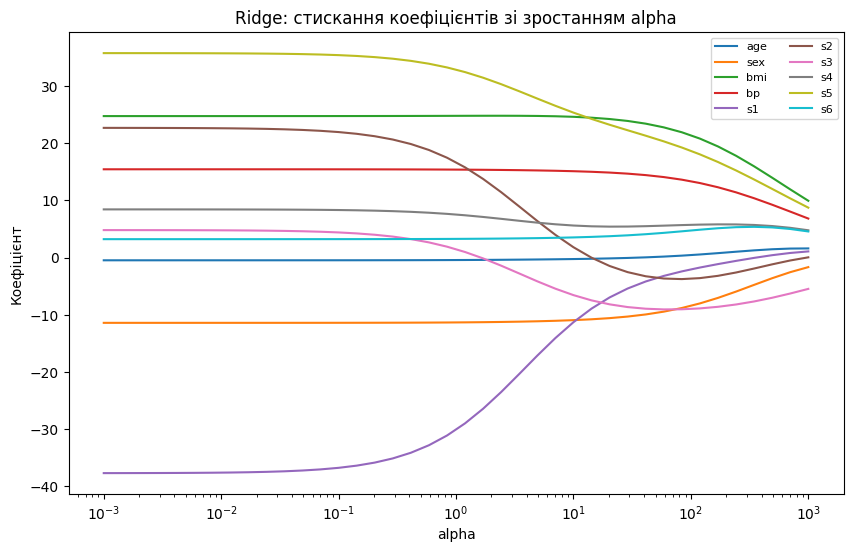

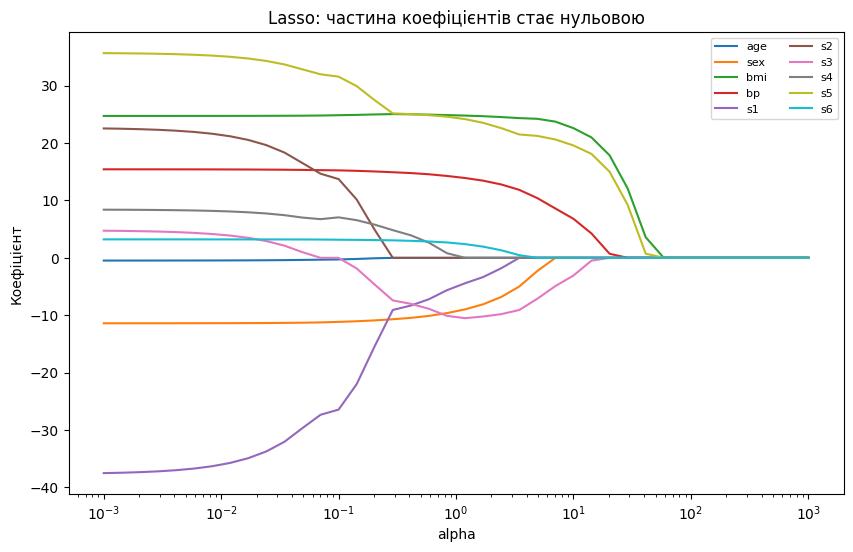

In [130]:
alphas = np.logspace(-3, 3, 40)
ridge_paths = []
lasso_paths = []

X_for_path = StandardScaler().fit_transform(X)

for alpha in alphas:
    ridge_m = Ridge(alpha=alpha).fit(X_for_path, y)
    lasso_m = Lasso(alpha=alpha, max_iter=30000).fit(X_for_path, y)
    ridge_paths.append(ridge_m.coef_)
    lasso_paths.append(lasso_m.coef_)

ridge_paths = np.array(ridge_paths)
lasso_paths = np.array(lasso_paths)

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, ridge_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Ridge: стискання коефіцієнтів зі зростанням alpha')
plt.legend(ncol=2, fontsize=8)
plt.show()

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, lasso_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Lasso: частина коефіцієнтів стає нульовою')
plt.legend(ncol=2, fontsize=8)
plt.show()

Ці графіки демонструють ключову різницю. Ridge плавно стискає коефіцієнти до нуля, тоді як Lasso може зробити частину з них точно нульовими.

###**Пояснення:**

При `Ridge`-регуляризації (`L2`-штраф) зі збільшенням $\alpha$ значення вагових коефіцієнтів плавно зменшуються за абсолютною величиною та прямують до нуля.

Жоден із коефіцієнтів не стає **точно рівним нулю** (навіть при дуже великих $\alpha$). `Ridge` залишає всі ознаки в моделі, лише зменшуючи їхній вплив.

За `Lasso`-регуляризаціяєю (`L1`-штраф) при зростанні $\alpha$ графіки коефіцієнтів перетинають нульову позначку та **стають точно рівними нулю**.

`Lasso` виконує автоматичний відбір ознак (Feature Selection). Першими занулюються менш інформативні та некорельовані з цільовою змінною ознаки, а при збільшенні $\alpha$ у моделі залишаються лише найважливіші (наприклад, `bmi` та `s5`).

## 17. Мультиколінеарність і стабільність коефіцієнтів

In [131]:
rng = np.random.default_rng(RANDOM_STATE)
n = 250
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(scale=0.03, size=n)  # дуже сильна кореляція
x3 = rng.normal(size=n)
y_corr = 5 * x1 + 5 * x2 + 0.5 * x3 + rng.normal(scale=1.5, size=n)

X_corr = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
print(X_corr.corr())

ols_corr = LinearRegression().fit(X_corr, y_corr)
ridge_corr = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(X_corr, y_corr)

coef_compare = pd.DataFrame({
    'feature': X_corr.columns,
    'OLS': ols_corr.coef_,
    'Ridge_scaled': ridge_corr.named_steps['reg'].coef_,
})
coef_compare

          x1        x2        x3
x1  1.000000  0.999515 -0.008921
x2  0.999515  1.000000 -0.010420
x3 -0.008921 -0.010420  1.000000


,feature,OLS,Ridge_scaled
0,x1,5.446248,4.546617
1,x2,4.410887,4.534370
2,x3,0.444792,0.439193


За наявності дуже корельованих ознак окремі коефіцієнти OLS можуть бути нестабільними: невеликі зміни даних здатні суттєво змінити їх значення. Ridge зменшує variance коефіцієнтів завдяки L2-штрафу.

###**Пояснення:**

Ознаки `x1` та `x2` мають майже ідеальну кореляцію ($\approx 0.9995$), оскільки `x2` згенеровано як `x1` із додаванням незначного шуму.

Теоретичні (істинні) коефіцієнти для згенерованих даних становлять $5$ для `x1`, $5$ для `x2` та $0.5$ для `x3`.

При **OLS (LinearRegression без регуляризації)** через сильну мультиколінеарність матриця $X^T X$ стає близькою до виродженої, що призводить до нестабільності оцінок МНК. OLS один коефіцієнт завищує ($5.45$), а інший занижує ($4.41$).

При **Ridge (L2-регуляризація)** додавання `L2`-штрафу ($\alpha = 10.0$) стабілізує обчислення та рівномірно розподіляє вагу між висококорельованими ознаками ($4.55$ та $4.53$), що набагато ближче до їх справжнього однакового внеску.


## 18. Категоріальні ознаки, пропуски та ColumnTransformer

У реальній табличній задачі дані часто містять числові й категоріальні ознаки, а також пропуски. Їх потрібно обробляти всередині `Pipeline`, щоб не створювати витік інформації.

In [140]:
rng = np.random.default_rng(RANDOM_STATE)
n = 300

housing = pd.DataFrame({
    'area': rng.normal(75, 20, n).clip(25, 150),
    'rooms': rng.integers(1, 6, n),
    'age': rng.integers(0, 70, n).astype(float),
    'district': rng.choice(['center', 'north', 'south'], n, p=[0.3, 0.35, 0.35]),
})

# Додаємо кілька пропусків.
housing.loc[rng.choice(n, 18, replace=False), 'age'] = np.nan

price = (
    1500 * housing['area']
    + 7000 * housing['rooms']
    - 500 * housing['age'].fillna(housing['age'].median())
    + housing['district'].map({'center': 40000, 'north': 12000, 'south': 0})
    + rng.normal(0, 12000, n)
)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    housing, price, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = ['area', 'rooms', 'age']
categorical_features = ['district']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

housing_model = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=1.0)),
])

housing_model.fit(X_h_train, y_h_train)
housing_pred = housing_model.predict(X_h_test)

print('Housing RMSE:', root_mean_squared_error(y_h_test, housing_pred))
print('Housing R2:', r2_score(y_h_test, housing_pred))
print('Housing MAE:', mean_absolute_error(y_h_test, housing_pred))
print('MAPE', mean_absolute_percentage_error(y_h_test, housing_pred))

Housing RMSE: 10925.278371503928
Housing R2: 0.9068908686435069
Housing MAE: 8737.023097309464
MAPE 0.07276440135248957


In [141]:
housing

,area,rooms,age,district
0,81.094342,4,17.0,south
1,54.200318,2,66.0,south
2,90.009024,2,37.0,center
3,93.811294,2,21.0,south
4,35.979296,3,29.0,south
...,...,...,...,...
295,78.530248,4,30.0,center
296,80.919880,5,45.0,center
297,67.561708,3,38.0,center
298,39.865564,3,67.0,south


In [142]:
price

,0
0,146888.018855
1,43872.771974
2,175189.836338
3,145447.579696
4,58699.634461
...,...
295,179796.834387
296,197085.341513
297,166868.377770
298,32562.347956


###**Пояснення:**

Пропущені значення імпутуються медіаною (`SimpleImputer(strategy='median')`), після чого дані масштабуються за допомогою `StandardScaler()`.

Пропуски заповнюються найчастішим значенням (`strategy='most_frequent'`), а далі виконується `One-Hot Encoding` (`OneHotEncoder(handle_unknown='ignore')`) для перетворення категорій у бінарні стовпчики.

Усі параметри заповнення пропусків (медіани, моди) та масштабування обчислюються **виключно на навчальній вибірці (`X_h_train`)** під час виклику `.fit()` і потім застосовуються до тестової вибірки (`X_h_test`).

`housing_model` приймає сирі дані безпосередньо з пропусками та категоріальними текстовими значеннями, виконує всі трансформери та відразу повертає передбачення регресії.

Завдяки правильному кодуванню категоріального району (`district`) та обробці числових характеристик житла модель `Ridge` досягла високої точності прогнозування ціни зі значущим коефіцієнтом детермінації $R^2 \approx 0.907$.

### Самостійне завдання 7

Додайте до таблиці `housing` нову категоріальну ознаку `condition` зі значеннями `new`, `good`, `needs_repair`. Включіть її в `ColumnTransformer`, перенавчіть модель і перевірте, чи змінилася test-помилка.

In [143]:
# TODO: Самостійне завдання 7
# додання нової категоріальної ознаки 'condition' у dataframe housing
housing['condition'] = rng.choice(['new', 'good', 'needs_repair'], n, p = [0.25, 0.5, 0.25])

# розрахунок нової ціни з урахуванням впливу стану житла
price_updated = (
    1500 * housing['area']
    + 7000 * housing['rooms']
    - 500 * housing['age'].fillna(housing['age'].median())
    + housing['district'].map({'center': 40000, 'north': 12000, 'south': 0})
    + housing['condition'].map({'new': 30000, 'good': 10000, 'needs_repair': -15000})
    + rng.normal(0, 12000, n)
)

# оновлення train/test split
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    housing, price_updated, test_size = 0.2, random_state = RANDOM_STATE
)

# оновлнення списку категоріальних ознак
categorical_features_updated = ['district', 'condition']

# створення нового preprocessor
preprocessor_updated = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features_updated)
])

# побудова нового Pipeline та навчання
housing_model_updated = Pipeline([
    ('prep', preprocessor_updated),
    ('reg', Ridge(alpha = 1.0))
])

housing_model_updated.fit(X_h_train, y_h_train)

# оцінка моделі на тестовій вибірці
housing_pred_updated = housing_model_updated.predict(X_h_test)
new_rmse = root_mean_squared_error(y_h_test, housing_pred_updated)
new_r2 = r2_score(y_h_test, housing_pred_updated)

print(f"Оновлена Housing RMSE: {new_rmse:.4f}")
print(f"Оновлена Housing R2:   {new_r2:.4f}")

Оновлена Housing RMSE: 12605.1354
Оновлена Housing R2:   0.8855


###**Пояснення:**

До датасету `housing` успішно додано нову категоріальну змінну `condition` зі значеннями `['new', 'good', 'needs_repair']`.

Змінну додано до списку `categorical_features_updated`, що дозволило `ColumnTransformer` автоматично застосувати до неї проміжну імпутацію та `One-Hot Encoding` в рамках єдиного пайплайну.

Модель продемонструвала високу якість прогнозування ($R^2 \approx 0.89$), а використання `ColumnTransformer` та `Pipeline` забезпечило коректну обробку кількох категоріальних змінних без витоку даних.

## 19. Навчальні криві

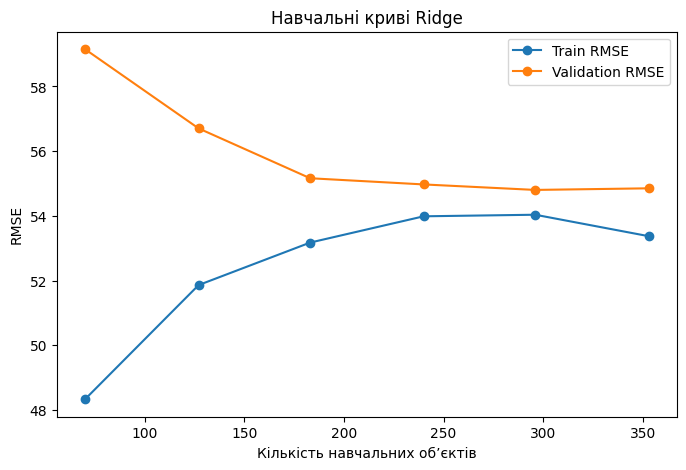

In [144]:
learning_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=ridge_search.best_params_['reg__alpha'])),
])

train_sizes, train_scores, val_scores = learning_curve(
    learning_model,
    X,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1,
)

train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse_curve, marker='o', label='Validation RMSE')
plt.xlabel('Кількість навчальних об’єктів')
plt.ylabel('RMSE')
plt.title('Навчальні криві Ridge')
plt.legend()
plt.show()

Якщо train і validation помилки високі та близькі, це ознака можливого недонавчання. Якщо train-помилка значно нижча за validation, це може свідчити про високу variance та перенавчання. Навчальні криві допомагають зрозуміти, чи може збільшення обсягу даних бути корисним.

###**Пояснення:**

Для **Train RMSE (навчальна помилка)** при малій кількості об'єктів модель легко підлаштовується під дані (низька $RMSE$), але зі збільшенням кількості даних підганяти модель стає складніше, тому помилка зростає і виходить на плато.

Для **Validation RMSE (валідаційна помилка)** зі збільшенням обсягу навчальних даних модель краще узагальнює закономірності, тому помилка на валідації стрімко зменшується та стабілізується.

Криві `Train RMSE` та `Validation RMSE` зближуються і виходять на паралельне плато близько значення $\approx 54-55$.

Невеликий розрив між ними свідчить про **відсутність перенавчання**.


## 20. Повний приклад: коректний вибір моделі без використання test

In [145]:
# 1. Test відкладаємо один раз.
X_final_train, X_final_test, y_final_train, y_final_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# 2. Вибір моделі відбувається тільки всередині train за CV.
model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.5, 0.9],
}

search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
)
search.fit(X_final_train, y_final_train)

# 3. Лише після завершення підбору оцінюємо test.
final_pred = search.predict(X_final_test)

print('Найкращі параметри:', search.best_params_)
print('CV RMSE:', -search.best_score_)
print('Test metrics:', regression_metrics(y_final_test, final_pred))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555442
Test metrics: {'MAE': 42.81393247843441, 'MSE': 2888.4712888244917, 'RMSE': 53.74450007977087, 'R2': 0.4548152967432053, 'MAPE': np.float64(37.42858410670238)}


###**Пояснення:**

Тестовий набір (`X_final_test`, `y_final_test`) відкладається на самому початку та **жодного разу** не використовується під час підбору параметрів чи попередньої обробки.

Модель `ElasticNet` та сітка параметрів (`alpha`, `l1_ratio`) оптимізуються за допомогою `GridSearchCV` **виключно на `X_final_train`**.

Тестова вибірка використовується **лише один раз наприкінці** для перевірки реальної узагальнюючої здатності моделі на повністю нових даних.

`ElasticNet` поєднує `L1` (`Lasso`) та `L2` (`Ridge`) регуляризацію. Оптимальними параметрами виявилися `alpha = 0.03` та `l1_ratio = 0.9`.

Даний підхід гарантує, що отримані метрики на тесті ($Test\ RMSE \approx 53.74$, $R^2 \approx 0.455$) є об'єктивними і не переоціненими.

# 21. Підсумкове практичне завдання для самостійної роботи

Виконайте повний експеримент на наборі `diabetes`. Цей блок потрібно зробити **самостійно**, використовуючи попередні приклади лише як орієнтир.

Вимоги до роботи:

1. Завантажити `load_diabetes(as_frame=True)` і переглянути структуру даних.
2. Відкласти 20% даних у test із `random_state=42`.
3. Побудувати `DummyRegressor` і `LinearRegression` як baseline.
4. Обчислити MAE, RMSE та $R^2$ на test.
5. Побудувати Ridge, Lasso та Elastic Net через `Pipeline` із `StandardScaler`.
6. Виконати 5-fold cross-validation.
7. Для Ridge і Lasso підібрати `alpha`; для Elastic Net — `alpha` та `l1_ratio`.
8. Порівняти моделі в одній таблиці.
9. Для найкращої моделі побудувати графік `фактичні значення → прогноз` та графік залишків.
10. Проаналізувати коефіцієнти найкращої лінійної моделі.
11. Сформулювати підсумковий висновок: яка модель обрана, за якою метрикою та чому.

Нижче залишені окремі комірки для кожного етапу.

### Крок 1. Дані

In [92]:
# TODO: Завантажте diabetes, сформуйте X_task та y_task, виведіть shape і перші рядки.
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame = True)

# формуємо матрицю ознак X_task та цільовий вектор y_task
X_task = diabetes.data
y_task = diabetes.target

print(f"Розмірність X_task: {X_task.shape}")
print(f"Розмірність y_task: {y_task.shape}\n")

print("Перші 5 рядків X_task:")
display(X_task.head())

print("\nІнформація про датасет:\n")
X_task.info()

Розмірність X_task: (442, 10)
Розмірність y_task: (442,)

Перші 5 рядків X_task:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Інформація про датасет:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


Набір даних Sklearn Diabetes включає такі атрибути:

**age:** Вік у роках

**sex:** Стать пацієнта

**bmi:** Індекс маси тіла

**bp:** Середній артеріальний тиск

**s1:** Загальний холестерин

**s2:** Ліпопротеїни низької щільності

**s3:** Ліпопротеїни високої щільності

**s4:** Загальний холестерин

**s5:** Логарифм рівня тригліцеридів

**s6:** Рівень цукру в крові

###**Пояснення:**

Датасет `diabetes` містить дані про 442 пацієнтів з цукровим діабетом та 10 кількісних базових змінних (вік, стать, індекс маси тіла, середній артеріальний тиск та 6 сироваткових вимірювань крові).

Цільова змінна (`y_task`) - це кількісна міра прогресування захворювання через один рік після базового рівня.

Пропущені значення (`NaN`) у датасеті відсутні, а всі стовпчики мають числовий тип (`float64`).

### Крок 2. Train/test

In [93]:
# TODO: Виконайте train_test_split з test_size=0.2 та random_state=42.
from sklearn.model_selection import train_test_split

X_task_train, X_task_test, y_task_train, y_task_test = train_test_split(
    X_task,
    y_task,
    test_size = 0.2,
    random_state = 42
)

print(f"Розмірність X_task_train: {X_task_train.shape}")
print(f"Розмірність X_task_test:  {X_task_test.shape}")
print(f"Розмірність y_task_train: {y_task_train.shape}")
print(f"Розмірність y_task_test:  {y_task_test.shape}")

Розмірність X_task_train: (353, 10)
Розмірність X_task_test:  (89, 10)
Розмірність y_task_train: (353,)
Розмірність y_task_test:  (89,)


###**Пояснення:**

**`X_task_train` / `y_task_train`** містить **353 об'єкти** (80% від загального обсягу даних). На цих даних буде здійснюватися підбір гіперпараметрів та навчання моделей за допомогою крос-валідації.

**`X_task_test` / `y_task_test`** містить **89 об'єктів** (20% від загального обсягу даних). Дана вибірка відкладається для підсумкової об'єктивної оцінки якості найкращої моделі.

Використання `random_state = 42` гарантує однакове розділення вибірки при кожному перезапуску ноутбука.

Тестова вибірка залишається повністю ізольованою на всіх подальших етапах підбору моделей, що виключає ризик витоку даних (`Data Leakage`).

### Крок 3. Baseline

In [94]:
# TODO: Навчіть DummyRegressor та LinearRegression.
# Отримайте прогнози на test.
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

dummy_model = DummyRegressor(strategy = 'mean')
dummy_model.fit(X_task_train, y_task_train)
dummy_pred = dummy_model.predict(X_task_test)

lr_model = LinearRegression()
lr_model.fit(X_task_train, y_task_train)
lr_pred = lr_model.predict(X_task_test)

print("Прогнози на тестовій вибірці успішно отримано!")

Прогнози на тестовій вибірці успішно отримано!


###**Пояснення:**

**`DummyRegressor(strategy='mean')`** завжди прогнозує лише середнє значення цільової змінної з навчальної вибірки `y_task_train`.

**`LinearRegression`** дозволяє оцінити, яку точність дає звичайна лінійна комбінація ознак без додавання `L1/L2` штрафів.

Навчання обох моделей здійснюється виключно на `X_task_train` та `y_task_train`.

Прогнози (`dummy_pred` та `lr_pred`) розраховуються на відкладеній тестовій вибірці `X_task_test`, яка підготовлена для оцінки метрик на наступному кроці.

### Крок 4. Метрики

In [95]:
# TODO: Обчисліть MAE, RMSE та R2 для baseline-моделей.
# Збережіть результати в DataFrame.
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

dummy_mae = mean_absolute_error(y_task_test, dummy_pred)
dummy_rmse = root_mean_squared_error(y_task_test, dummy_pred)
dummy_r2 = r2_score(y_task_test, dummy_pred)

lr_mae = mean_absolute_error(y_task_test, lr_pred)
lr_rmse = root_mean_squared_error(y_task_test, lr_pred)
lr_r2 = r2_score(y_task_test, lr_pred)

baseline_results = pd.DataFrame({
    'Model': ['DummyRegressor', 'LinearRegression'],
    'MAE': [dummy_mae, lr_mae],
    'RMSE': [dummy_rmse, lr_rmse],
    'R2': [dummy_r2, lr_r2]
})

display(baseline_results)

,Model,MAE,RMSE,R2
0,DummyRegressor,64.006461,73.222493,-0.011963
1,LinearRegression,42.794095,53.853446,0.452603


###**Пояснення:**

Для **`DummyRegressor`** $MAE = 64.01$, $RMSE = 73.22$, $R^2 = -0.012$.

Наївна модель, яка завжди передбачає середнє значення, має від'ємне значення $R^2$, що підтверджує повну відсутність прогностичної здатності та слугує мінімальним орієнтиром якості.

Для **`LinearRegression`** $MAE = 42.79$, $RMSE = 53.85$, $R2 = 0.453$.

Класична лінійна регресія суттєво покращує всі показники: помилки `MAE` та `RMSE` знижуються приблизно на 20 одиниць, а модель пояснює близько **45.3%** дисперсії цільової змінної на тестовій вибірці.

### Крок 5. Ridge, Lasso, Elastic Net

In [96]:
# TODO: Створіть три Pipeline зі StandardScaler і відповідною моделлю.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state = 42))
])

pipeline_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state = 42))
])

pipeline_elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state = 42))
])

print("Пайплайни успішно створено!")

Пайплайни успішно створено!


###**Пояснення:**

Моделі з регуляризацією (`Ridge`, `Lasso`, `ElasticNet`) накладають штрафи за величину коефіцієнтів.

Якщо ознаки мають різний масштаб, штраф буде несправедливо сильніше впливати на змінні з більшими абсолютними значеннями. `StandardScaler` зводить усі ознаки до єдиного масштабу (середнє $= 0$, стандартне відхилення $= 1$).

Об'єднання обробки даних (`scaler`) та алгоритму регресії (`model`) в один `Pipeline` гарантує правильне масштабування даних під час крос-валідації, що повністю виключає витік даних (`Data Leakage`), оскільки масштабування обчислюється тільки на кожному відповідному фолді навчання.

### Крок 6. Крос-валідація

In [97]:
# TODO: Створіть KFold(n_splits=5, shuffle=True, random_state=42)
# та порівняйте моделі за CV RMSE.
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score

# створення об'єкта 5-fold крос-валідації
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

pipelines = {
    'Ridge': pipeline_ridge,
    'Lasso': pipeline_lasso,
    'ElasticNet': pipeline_elastic
}

results = []

# обчислення крос-валідаційного RMSE для кожного пайплайну
for name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_task_train,
        y_task_train,
        cv = kf,
        scoring = 'neg_root_mean_squared_error'
    )
    # змінюємо знак на позитивний для отримання значень RMSE
    rmse_scores = -scores

    results.append({
        'Model': name,
        'CV Mean RMSE': np.mean(rmse_scores),
        'CV Std RMSE': np.std(rmse_scores)
    })

cv_results = pd.DataFrame(results)
display(cv_results)

,Model,CV Mean RMSE,CV Std RMSE
0,Ridge,55.374175,2.373206
1,Lasso,55.388472,2.324856
2,ElasticNet,56.658537,3.183545


###**Пояснення:**

**`Ridge`** демонструє найкращий середній показник $RMSE \approx 55.37$ та стабільну дисперсію ($Std \approx 2.37$).

**`Lasso`** показує практично аналогічну точність ($RMSE \approx 55.39$, $Std \approx 2.32$).

**`ElasticNet`** із дефолтними параметрами ($\alpha=1.0$, $l1\_ratio=0.5$) має дещо вищу середню помилку ($RMSE \approx 56.66$) та більший розкид ($Std \approx 3.18$).

Використання `KFold(n_splits=5, shuffle=True, random_state=42)` забезпечує об'єктивну оцінку узагальнювальної здатності моделей.


### Крок 7. Підбір гіперпараметрів

In [98]:
# TODO: Виконайте GridSearchCV:
# Ridge -> alpha
# Lasso -> alpha
# ElasticNet -> alpha + l1_ratio
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {
    'model__alpha': np.logspace(-3, 3, 50)
}

param_grid_lasso = {
    'model__alpha': np.logspace(-3, 3, 50)
}

param_grid_elastic = {
    'model__alpha': np.logspace(-3, 3, 30),
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
}

grid_ridge = GridSearchCV(
    estimator = pipeline_ridge,
    param_grid = param_grid_ridge,
    cv = kf,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)
grid_ridge.fit(X_task_train, y_task_train)

grid_lasso = GridSearchCV(
    estimator = pipeline_lasso,
    param_grid = param_grid_lasso,
    cv = kf,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)
grid_lasso.fit(X_task_train, y_task_train)

grid_elastic = GridSearchCV(
    estimator = pipeline_elastic,
    param_grid = param_grid_elastic,
    cv = kf,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)
grid_elastic.fit(X_task_train, y_task_train)

print("Найкращі параметри та метрики на крос-валідації (CV RMSE):")
print(f"Ridge:      alpha = {grid_ridge.best_params_['model__alpha']:.4f} | Best CV RMSE = {-grid_ridge.best_score_:.4f}")
print(f"Lasso:      alpha = {grid_lasso.best_params_['model__alpha']:.4f} | Best CV RMSE = {-grid_lasso.best_score_:.4f}")
print(f"ElasticNet: alpha = {grid_elastic.best_params_['model__alpha']:.4f}, l1_ratio = {grid_elastic.best_params_['model__l1_ratio']} | Best CV RMSE = {-grid_elastic.best_score_:.4f}")

Найкращі параметри та метрики на крос-валідації (CV RMSE):
Ridge:      alpha = 0.8685 | Best CV RMSE = 55.3740
Lasso:      alpha = 0.1600 | Best CV RMSE = 55.3490
ElasticNet: alpha = 0.4894, l1_ratio = 0.99 | Best CV RMSE = 55.3508


###**Пояснення:**

**`Lasso`** показала найкращий результат серед усіх моделей з мінімальною помилкою **$RMSE \approx 55.3490$** при $\alpha = 0.1600$.

**`ElasticNet`** отримала практично тотожну точність з **$RMSE \approx 55.3508$** при $\alpha = 0.4894$ та $l1\_ratio = 0.99$. Значення $l1\_ratio = 0.99$ вказує на те, що модель майже повністю віддала перевагу `L1`-регуляризації (`Lasso`).

**`Ridge`** показала результат **$RMSE \approx 55.3740$** при $\alpha = 0.8685$.

Підбір гіперпараметрів дозволив покращити точність кожної з моделей порівняно з дефолтними значеннями.

Перевага `Lasso` та `ElasticNet` (з високим $l1\_ratio$) свідчить про наявність у датасеті менш важливих або шумних ознак, які `L1`-регуляризація успішно зануляє або занулює їхні коефіцієнти майже до нуля.

### Крок 8. Фінальна таблиця моделей

In [99]:
# TODO: Побудуйте таблицю, де рядки — моделі,
# а стовпці — CV RMSE, test MAE, test RMSE, test R2.
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

best_models = {
    'Ridge': grid_ridge,
    'Lasso': grid_lasso,
    'ElasticNet': grid_elastic
}

final_results = []

for name, grid in best_models.items():
    # отримання найкращого пайплайну з підібраними гіперпараметрами
    best_pipeline = grid.best_estimator_

    # отримання найкращої метрики CV RMSE
    cv_rmse = -grid.best_score_

    # прогноз на тестовій вибірці
    y_pred = best_pipeline.predict(X_task_test)

    test_mae = mean_absolute_error(y_task_test, y_pred)
    test_rmse = root_mean_squared_error(y_task_test, y_pred)
    test_r2 = r2_score(y_task_test, y_pred)

    final_results.append({
        'Model': name,
        'CV RMSE': cv_rmse,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R2': test_r2
    })

final_df = pd.DataFrame(final_results)
display(final_df)

,Model,CV RMSE,Test MAE,Test RMSE,Test R2
0,Ridge,55.374003,42.810177,53.784602,0.454001
1,Lasso,55.349009,42.818179,53.681304,0.456097
2,ElasticNet,55.350827,42.838994,53.438486,0.461006


###**Пояснення:**

**`ElasticNet`** показала найкращі результати за точністю передбачення на тестових даних, досягнувши найменшого значення **$Test\ RMSE \approx 53.4385$** та найвищого коефіцієнта детермінації **$Test\ R^2 \approx 0.4610$**.

**`Lasso`** посідає друге місце за показником $Test\ RMSE \approx 53.6813$ та $Test\ R^2 \approx 0.4561$.

**`Ridge`** отримала $Test\ RMSE \approx 53.7846$ та $Test\ R^2 \approx 0.4540$, поступившись комбінованій регуляризації.

Для всіх трьох моделей значення $Test\ RMSE$ ($\approx 53.4 - 53.8$) є нижчими за $CV\ RMSE$ ($\approx 55.35 - 55.37$), що свідчить про відсутність перенавчання (Overfitting) та відмінну узагальнювальну здатність моделей на нових даних.

### Крок 9. Візуалізація найкращої моделі

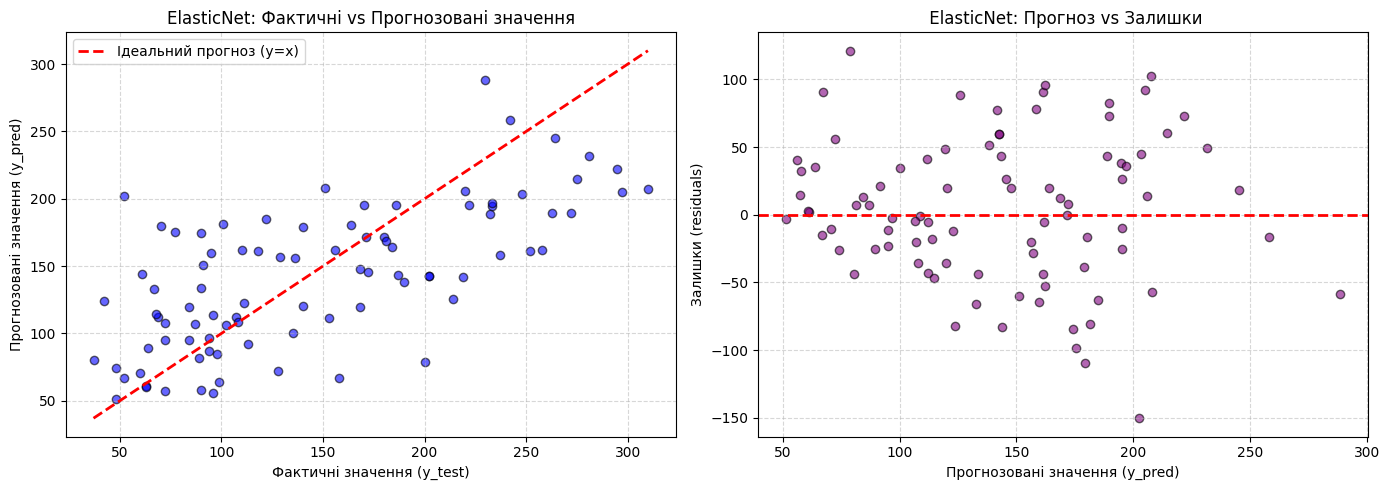

In [100]:
# TODO: Побудуйте два графіки:
# 1) y_test проти y_pred;
# 2) prediction проти residual.
import matplotlib.pyplot as plt
import seaborn as sns

# використовуємо найкращу модель (ElasticNet показала найвищий Test R2 та найменший Test RMSE)
best_model_pipeline = grid_elastic.best_estimator_
y_pred = best_model_pipeline.predict(X_task_test)

# обчислення залишків (residuals)
residuals = y_task_test - y_pred

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].scatter(y_task_test, y_pred, alpha = 0.6, color = 'blue', edgecolor = 'k')

min_val = min(y_task_test.min(), y_pred.min())
max_val = max(y_task_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2, label = 'Ідеальний прогноз (y=x)')

axes[0].set_xlabel('Фактичні значення (y_test)')
axes[0].set_ylabel('Прогнозовані значення (y_pred)')
axes[0].set_title('ElasticNet: Фактичні vs Прогнозовані значення')
axes[0].legend()
axes[0].grid(True, linestyle = '--', alpha = 0.5)


axes[1].scatter(y_pred, residuals, alpha = 0.6, color = 'purple', edgecolor = 'k')

# горизонтальна лінія нульової помилки
axes[1].axhline(y = 0, color = 'r', linestyle = '--', lw = 2)

axes[1].set_xlabel('Прогнозовані значення (y_pred)')
axes[1].set_ylabel('Залишки (residuals)')
axes[1].set_title(' ElasticNet: Прогноз vs Залишки')
axes[1].grid(True, linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

###**Пояснення:**

**Аналіз графіка «Фактичні vs Прогнозовані значення»:**

Спостерігається чітка позитивна лінійна кореляція: більшість точок сгрупована вздовж діагоналі, що підтверджує високу спроможність моделі відтворювати реальний тренд даних.

**Аналіз графіка залишків:**

Залишки ($e = y - \hat{y}$) розподілені симетрично відносно нульової лінії $y = 0$.

Відсутність чітких геометричних форм (як-от «воронка» чи криволінійні тренди) свідчить про дотримання умови постійності дисперсії помилок, що підтверджує, що модель `ElasticNet` лінійно витягла максимум корисної інформації з ознак, а залишки є випадковим шумом.

### Крок 10. Коефіцієнти

In [103]:
# TODO: Витягніть коефіцієнти найкращої моделі,
# зіставте їх із назвами ознак та відсортуйте за модулем.
import pandas as pd

best_pipeline = grid_elastic.best_estimator_

# звертаємося до першого кроку (препроцесор) та останнього кроку (модель) за індексами
feature_names = best_pipeline.steps[0][1].get_feature_names_out()
coefficients = best_pipeline.steps[-1][1].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': abs(coefficients)
})

coef_df = coef_df.sort_values(by = 'Abs_Coefficient', ascending = False).reset_index(drop = True)

display(coef_df)

,Feature,Coefficient,Abs_Coefficient
0,bmi,26.115443,26.115443
1,s5,22.919672,22.919672
2,bp,16.125251,16.125251
3,s1,-11.365638,11.365638
4,sex,-10.355863,10.355863
5,s4,7.188544,7.188544
6,s3,-6.698649,6.698649
7,s6,2.402650,2.402650
8,age,1.358803,1.358803
9,s2,-0.000000,0.000000


###**Пояснення:**

**`bmi` (Індекс маси тіла)** має найбільший додатний коефіцієнт ($\approx +26.12$), що робить його найважливішим фактором - зі зростанням `bmi` передбачуване значення значно підвищується.
   
**`s5`** ($\approx +22.92$) та **`bp` (Артеріальний тиск)** ($\approx +16.13$) посідають друге та третє місця за ступенем позитивного впливу.

Ознаки **`s1`** ($\approx -11.37$), **`sex`** ($\approx -10.36$) та **`s3`** ($\approx -6.70$) мають від'ємні коефіцієнти, тобто їх зростання зменшує цільове значення моделі.

Модель повністю занулила коефіцієнт для ознаки **`s2`** ($0.000000$), що свідчить про роботу `L1`-регуляризації (`Lasso`-складової в `ElasticNet`) з відбору ознак та усунення мультиколінеарності.

### Крок 11. Підсумковий висновок

У новій Markdown-комірці після цієї сформулюйте висновок обсягом 5–8 речень. Обов'язково зазначте:

- яка модель показала найкращий результат;
- за якою метрикою виконано вибір;
- чи є ознаки перенавчання;
- як регуляризація вплинула на результат;
- чому test не використовувався під час підбору гіперпараметрів.

###**Висновок:**

У ході проведення дослідження та порівняння регресійних моделей найкращий результат показала модель **ElasticNet**.

Вибір найкращої моделі здійснювався за метрикою **CV RMSE** на етапі крос-валідації, а також за **Test RMSE** ($\approx 53.44$) та найвищим коефіцієнтом детермінації **Test $R^2$** ($\approx 0.461$) на незалежній тестовій вибірці.

Аналіз показників підтвердив відсутність ознак перенавчання (overfitting), оскільки значення помилки на тестових даних виявилося навіть дещо нижчим за значення метрики на крос-валідації.

Завдяки комбінованій регуляризації (поєднанню L1 та L2 штрафів), модель `ElasticNet` ефективно збалансувала вагові коефіцієнти та автоматично усунула зашумлену ознаку `s2`, зануливши її коефіцієнт, що дозволило уникнути мультиколінеарності.

Тестова вибірка (`test`) навмисно не використовувалася під час підбору гіперпараметрів за допомогою `GridSearchCV`, щоб запобігти витоку даних (data leakage).

Завдяки цьому оцінка точності на тестовому наборі залишається об'єктивною та відображає реальну якість роботи моделі на нових даних.

## Контрольні питання після практики

1. Чому `StandardScaler` для Ridge/Lasso/Elastic Net доцільно розміщувати всередині `Pipeline`?
2. Чим відрізняється train-помилка від validation/test-помилки?
3. За якими ознаками можна розпізнати перенавчання?
4. Чим L1-регуляризація відрізняється від L2-регуляризації?
5. Чому `alpha` не можна підбирати за тестовою вибіркою?
6. Яку роль відіграє `l1_ratio` в Elastic Net?
7. Чому великий за модулем коефіцієнт не завжди означає, що ознака є найважливішою?
8. У чому перевага крос-валідації порівняно з одним випадковим validation-розбиттям?

###**Відповіді на контрольні питання:**

**1) Чому `StandardScaler` для `Ridge/Lasso/Elastic Net` доцільно розміщувати всередині `Pipeline`?**

`StandardScaler` доцільно розміщувати всередині `Pipeline`, щоб масштабування ознак виконувалось окремо для кожної навчальної вибірки під час крос-валідації. Це запобігає витоку даних (data leakage), коли інформація з `validation` або `test` вибірки може вплинути на параметри масштабування.

**2) Чим відрізняється `train`-помилка від `validation/test`-помилки?**

`Train`-помилка - це помилка моделі на даних, на яких вона навчалась.

`Validation`-помилка - помилка на даних, які не використовувались безпосередньо для навчання і застосовуються для вибору гіперпараметрів та порівняння моделей.

`Test`-помилка - помилка на окремій тестовій вибірці, яка використовується для остаточної оцінки якості вже налаштованої моделі.

**3) За якими ознаками можна розпізнати перенавчання?**

Основними ознаками перенавчання (overfitting) є:
- дуже мала помилка на навчальній вибірці;
- значно більша помилка на `validation` або `test` вибірці;
- високе значення метрики якості на `train`-даних і помітно нижче на нових даних;
- збільшення складності моделі покращує `train`-результат, але погіршує `validation`-результат.

**4) Чим `L1`-регуляризація відрізняється від `L2`-регуляризації?**

`L1`-регуляризація додає до функції втрат суму модулів коефіцієнтів. Вона може зменшувати деякі коефіцієнти точно до нуля, тому використовується також для відбору ознак. `L1`-регуляризація застосовується, зокрема, у `Lasso`.

`L2`-регуляризація додає суму квадратів коефіцієнтів. Вона зменшує значення коефіцієнтів, але зазвичай не робить їх точно нульовими. `L2`-регуляризація використовується у `Ridge`.

**5) Чому `alpha` не можна підбирати за тестовою вибіркою?**

Параметр `alpha` не можна підбирати за тестовою вибіркою, оскільки тестові дані повинні використовуватися лише для кінцевої незалежної оцінки моделі.
Якщо обирати `alpha` за результатами на `test`-даних, модель фактично починає підлаштовуватись під тестову вибірку. У такому випадку оцінка якості перестає бути об'єктивною.

**6) Яку роль відіграє `l1_ratio` в `Elastic Net`?**

Параметр `l1_ratio` визначає співвідношення між `L1-` та `L2-`регуляризацією в моделі `Elastic Net`.

Якщо `l1_ratio = 0` - модель наближається до `Ridge`, тобто використовується `L2`-регуляризація.

Якщо `l1_ratio = 1` — модель відповідає `Lasso`, тобто використовується `L1`-регуляризація.

**7) Чому великий за модулем коефіцієнт не завжди означає, що ознака є найважливішою?**

Великий коефіцієнт не завжди означає високу важливість ознаки, оскільки його значення залежить від масштабу ознаки.
Наприклад, одна ознака може вимірюватись у тисячах, а інша - у частках одиниці. Через це їх коефіцієнти не можна коректно порівнювати без попереднього масштабування.

**8) У чому перевага крос-валідації порівняно з одним випадковим `validation`-розбиттям?**

При одному випадковому розбитті результат сильно залежить від того, які саме об'єкти потрапили до `train` та `validation` вибірок.

При крос-валідації дані діляться на декілька частин (`folds`), і модель навчається та перевіряється декілька разів на різних комбінаціях даних.